# Duration vs. Campaign Success

## Objective

This analysis explores the relationship between Kickstarter campaign duration and campaign success.

The analysis will:
- Examine the distribution of campaign duration
- Compare duration between successful and failed campaigns
- Investigate whether shorter or longer campaign durations show different success patterns
- Document key findings for future feature selection and modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the filtered Kickstarter dataset
df = pd.read_csv("../data/kickstarter_us_filtered.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38504, 17)


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
3,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00
4,316217,Dinner Party - a short film about friendship.....,http://www.kickstarter.com/projects/249354515/...,Film & Video,Short Film,"Portland, OR",successful,3500.0,3582.0,1.023331,39,"Wed, 22 Jun 2011 13:33:00 -0000",7,"$5,$25,$50,$100,$250,$500,$1,000",8,0,21.43


In [4]:
# Verify duration has no missing values and the data type
print("Missing duration values:", df["duration"].isnull().sum())
print("Duration data type:", df["duration"].dtype)
df["duration"].describe()

Missing duration values: 0
Duration data type: float64


count    38504.000000
mean        39.813501
std         17.442748
min          1.000000
25%         30.000000
50%         31.895000
75%         47.462500
max         91.960000
Name: duration, dtype: float64

## Compare Duration by Campaign Outcome

Before visualizing the data, compare summary statistics for campaign duration between successful and failed campaigns.

In [5]:
# Compare duration statistics between successful and failed campaigns
df.groupby("status")["duration"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
failed,17429.0,42.55,18.39,1.0,30.0,35.00,59.36,91.96
successful,21075.0,37.55,16.27,1.0,30.0,30.96,45.00,91.96


In [7]:
# Check how many campaigns lasted longer than 60 days
long_campaigns = df[df["duration"] > 60]
print("Campaigns longer than 60 days:", len(long_campaigns))
long_campaigns[["name", "duration", "status"]].sort_values("duration", ascending=False).head(20)

Campaigns longer than 60 days: 4267


,name,duration,status
5035,'Do What You Love' Live your Dreams - a P. J...,91.96,failed
3872,Wales &amp; The Welsh - the shaping of a peopl...,91.96,failed
5477,Angie McClure's new album,91.96,successful
10984,once upon a mountain,91.96,failed
8343,The Secrets To Life,91.96,failed
26708,&quot;Distribution Point&quot; Demo Shoot,91.96,failed
2565,Traditions Build Winners as the Snipe Class tu...,91.96,successful
19839,Fair Trade Fashion by SET Boutique,91.96,failed
24559,SmoothnFusion Jazz Comedy Album,91.96,failed
31427,Misisipi Mike Wolf's 2nd Album - Enjoy Irrespo...,91.96,successful


In [8]:
# Look at the upper end of the duration distribution
df["duration"].quantile([0.90, 0.95, 0.99]) 

0.90    60.040
0.95    77.547
0.99    90.040
Name: duration, dtype: float64

## Campaign Duration Visualization

Visualize the distribution of campaign duration for successful and failed campaigns.

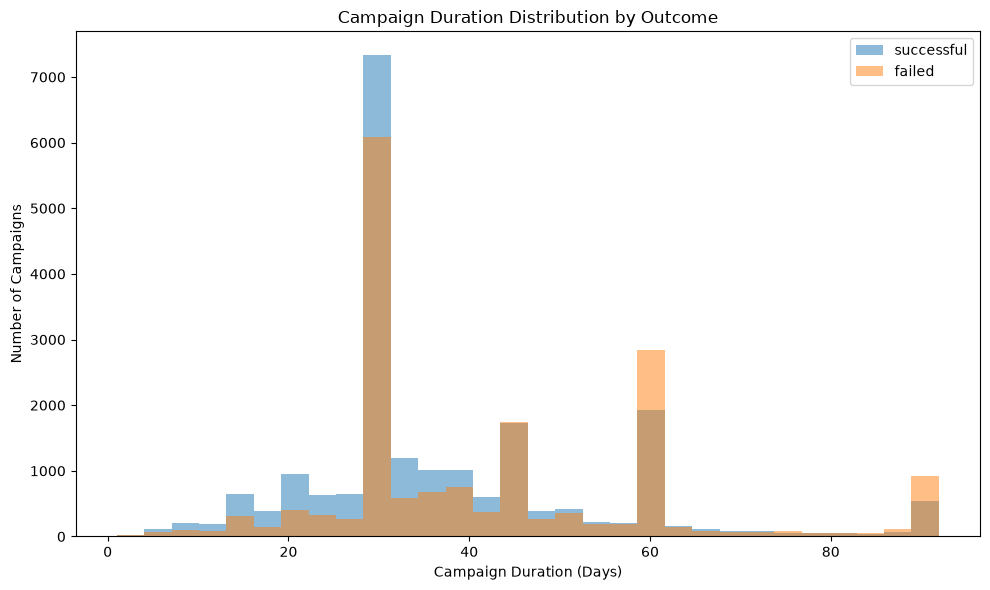

In [9]:
plt.figure(figsize=(10, 6))

for outcome in ["successful", "failed"]:
    subset = df[df["status"] == outcome]

    plt.hist(
        subset["duration"],
        bins=30,
        alpha=0.5,
        label=outcome
    )

plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Number of Campaigns")
plt.title("Campaign Duration Distribution by Outcome")
plt.legend()

plt.tight_layout()
plt.show()

## Success Rate by Campaign Duration

Campaigns are grouped into duration ranges to compare the observed success rate across shorter and longer campaigns.

In [ ]:
# Create duration group
df["duration_group"] = pd.cut(
    df["duration"],
    bins=[0, 30, 45, 60, float("inf")],
    labels=["≤30 days", "30–45 days", "45–60 days", ">60 days"]
)

In [ ]:
# Create a binary column for successful campaigns
df["is_successful"] = (df["status"] == "successful").astype(int)

In [ ]:
# Calculate success rate 
duration_success = (
    df.groupby("duration_group", observed=True)
    .agg(
        total_campaigns=("status", "size"),
        successful_campaigns=("is_successful", "sum"),
        success_rate=("is_successful", "mean")
    )
)
duration_success["success_rate"] *= 100
duration_success.round(2)

,total_campaigns,successful_campaigns,success_rate
duration_group,,,
≤30 days,16597,9652,58.16
30–45 days,10951,6427,58.69
45–60 days,6689,3148,47.06
>60 days,4267,1848,43.31


## Duration Success Rate Visualization

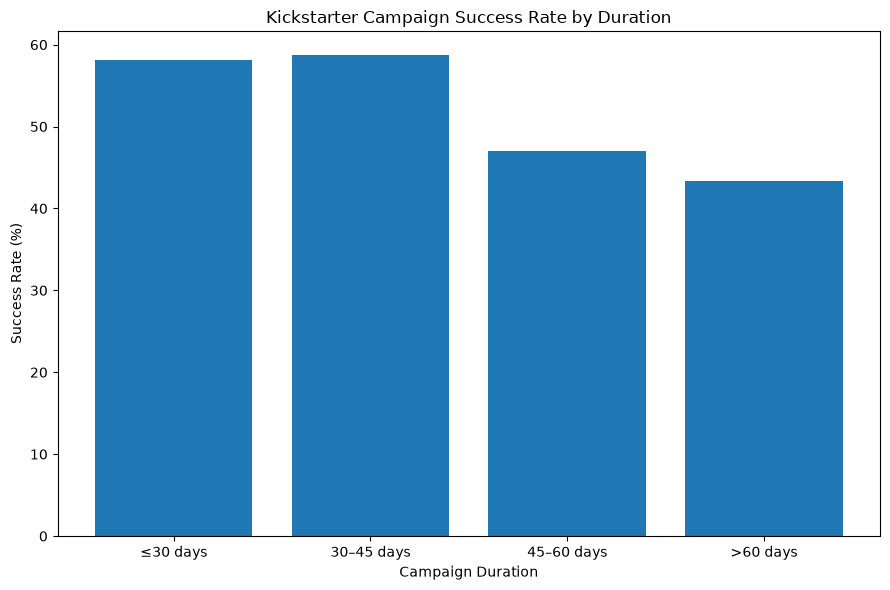

In [14]:
plt.figure(figsize=(9, 6))

plt.bar(
    duration_success.index.astype(str),
    duration_success["success_rate"]
)

plt.xlabel("Campaign Duration")
plt.ylabel("Success Rate (%)")
plt.title("Kickstarter Campaign Success Rate by Duration")

plt.tight_layout()
plt.show()

## Findings

- Successful campaigns has around 30-45 days of campaigns
- Campaigns longer than 60 days tend to have lower success rate
- Shorter campaigns doesn't mean better success rate too, it has to be enough like in the middle a month minimum but not until 2 month
- These results suggest that campaign duration may be associated with campaign success, but they do not establish that shorter duration directly causes higher success.
- Duration may therefore be worth evaluating during feature selection and modeling.
- I'm wondering tho since success campaigns is 21k and failed one is 17k so it's not really accurate or fair to directly count the percentage or the rate of success in relation to duration just 1:1 like that, there must be something that like you know be a benchmark or something that makes it equivalent 21k:17k do u get what i mean? or did we do this somewhere?
